Models:
- Logistic Regression
- Tree Decision
- Random Forest
- CatBoost
- XGBoost

For imbalance fix:
- `class-weight`
- `undersampling` & `oversampling`
- `SMOTE`

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (precision_score,
                             recall_score,
                             average_precision_score,
                             f1_score)

import joblib

In [2]:
RANDOM_SEED = 42
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

## New Features

In [3]:
df['log_amount'] = np.log1p(df['amount'])
df['day'] = (df['step'] - 1) // 24
df['hour'] = (df['step'] - 1) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['step', 'type',
            'amount', 'log_amount',
            'day', 'hour_sin',
            'hour_cos']

target = ['isFraud']

df = df[features + target]

df['type'] = df['type'].astype('category')

In [4]:
test_point = 550
calibration_point = test_point - 50
validation_point = calibration_point - 100

test = df[df['step'] > test_point].copy()
calibration = df[(df['step'] <= test_point) & (df['step'] > calibration_point)].copy()
validation = df[(df['step'] <= calibration_point) & (df['step'] > validation_point)].copy()
train = df[df['step'] <= validation_point].copy()

In [5]:
X_train, y_train = train.drop('isFraud', axis=1), train['isFraud']
X_val, y_val = validation.drop('isFraud', axis=1), validation['isFraud']
X_cal, y_cal = calibration.drop('isFraud', axis=1), calibration['isFraud']
X_test, y_test = test.drop('isFraud', axis=1), test['isFraud']

In [6]:
categorial_features = ['type']
numeric_features = ['amount', 'log_amount']
other_features =['step', 'day', 'hour_sin', 'hour_cos']

## Pipelines

### Logistic Regression

#### Logistic Regression Preprocessing

In [7]:
log_reg_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### Logistic Regression Pipelines

In [8]:
log_reg_models = {
    'base': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_SEED)
        )
    ]),

    'balanced': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ])
}

### Decision Tree Classifier

#### Decision Tree Preprocessor

In [9]:
dt_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Decision Tree Pipelines

In [10]:
dt_pipelines = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ])
}

### Random Forest

#### Random Forest Preprocessor

In [11]:
rf_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Random Forest Pipelines

In [12]:
rf_pipelines = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ])
}

### XGBoost

#### XGBoost Pipelines

In [13]:
xgb_pipelines = {

    'base': Pipeline(steps=[
        ('classifier', XGBClassifier(
            enable_categorical=True,
            n_jobs=-1,
            random_state=RANDOM_SEED
        ))
    ])
}

### Catboost

#### Catboost Pipelines

In [ ]:
cb_models = {
    'base': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        random_seed=RANDOM_SEED,
        verbose=False
    ),

    'balanced': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        auto_class_weights='Balanced',

        random_seed=RANDOM_SEED,
        verbose=False
    )
}

### Light Gradient Boosting

#### LGBM Pipelines

In [ ]:
lgbm_pipelines = {

    # base
    'base': Pipeline(steps=[
        ('classifier', LGBMClassifier(
            objective='binary',
            n_estimators=300,
            learning_rate=0.1,
            num_leaves=31,
            max_depth=8,
            min_child_samples=50,
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            n_jobs=-1,
            verbosity=-1,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('classifier', LGBMClassifier(
            class_weight='balanced',
            objective='binary',
            n_estimators=300,
            learning_rate=0.1,
            num_leaves=31,
            max_depth=8,
            min_child_samples=50,
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            n_jobs=-1,
            verbosity=-1,
            random_state=RANDOM_SEED
        ))
    ])
}

### Results

In [ ]:
sampling_strategies = {
    'base': None,

    'under.05': RandomUnderSampler(
        sampling_strategy=0.05,
        random_state=RANDOM_SEED
    ),

    'under.10': RandomUnderSampler(
        sampling_strategy=0.10,
        random_state=RANDOM_SEED
    ),

    'under.20': RandomUnderSampler(
        sampling_strategy=0.20,
        random_state=RANDOM_SEED
    ),

    'over.005': RandomOverSampler(
        sampling_strategy=0.005,
        random_state=RANDOM_SEED
    ),

    'over.01': RandomOverSampler(
        sampling_strategy=0.01,
        random_state=RANDOM_SEED
    ),

    'over.02': RandomOverSampler(
        sampling_strategy=0.02,
        random_state=RANDOM_SEED
    ),

    'smote.01': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.01,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),

    'smote.02': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.02,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),
}

In [ ]:
def apply_sampling(X, y, sampler):
    if sampler is None:
        return X.copy(), y.copy()

    X_resampled, y_resampled = sampler.fit_resample(X, y)

    X_resampled['type'] = X_resampled['type'].astype('category')

    return X_resampled, y_resampled

In [ ]:
def model_estimation(y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    average_precision = average_precision_score(y_true, y_proba)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'average_precision': average_precision,
    }

In [ ]:
def evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        sampler=None,
        fit_params=None
):
    X_sampled, y_sampled = apply_sampling(
        X_train,
        y_train,
        sampler
    )

    start = time.time()

    if fit_params is None:
        fit_params = {}

    model.fit(
        X_sampled,
        y_sampled,
        **fit_params
    )

    training_time = time.time() - start

    y_proba = model.predict_proba(X_val)[:, 1]

    metrics = model_estimation(
        y_val,
        y_proba
    )

    metrics['Model'] = model_name
    metrics['training_time'] = training_time

    return model, metrics

In [ ]:
res_val_table = pd.DataFrame(
    columns=[
        'model',
        'sampling',
        'precision',
        'recall',
        'f1',
        'average_precision'
    ]
)

In [20]:
res_val_table.sort_values(by='average_precision', ascending=False)

,model,sampling,precision,recall,f1,average_precision
57,LGBM,smote.02,0.028501,0.874539,0.055203,0.382413
56,LGBM,smote.01,0.028501,0.874539,0.055203,0.382413
55,LGBM,over.02,0.028501,0.874539,0.055203,0.382413
54,LGBM,over.01,0.028501,0.874539,0.055203,0.382413
53,LGBM,over.005,0.028501,0.874539,0.055203,0.382413
52,LGBM,under.20,0.028501,0.874539,0.055203,0.382413
51,LGBM,under.10,0.028501,0.874539,0.055203,0.382413
50,LGBM,under.05,0.028501,0.874539,0.055203,0.382413
49,LGBM,balanced,0.028501,0.874539,0.055203,0.382413
28,Random Forest,smote.01,0.217537,0.418819,0.286345,0.262725


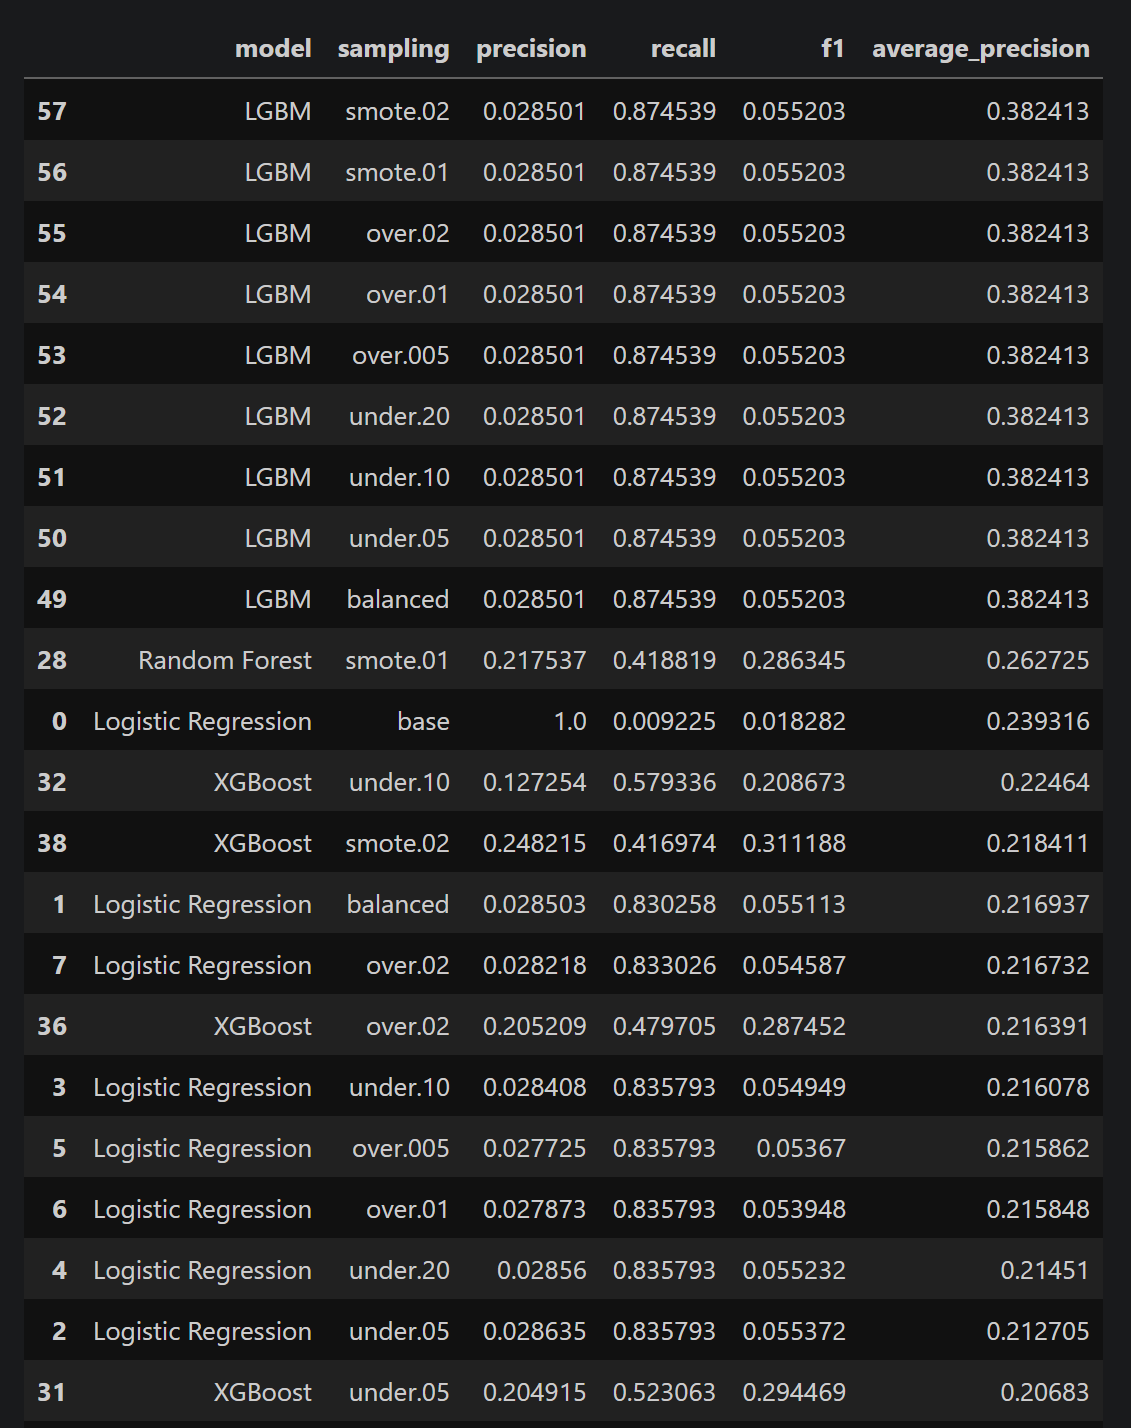
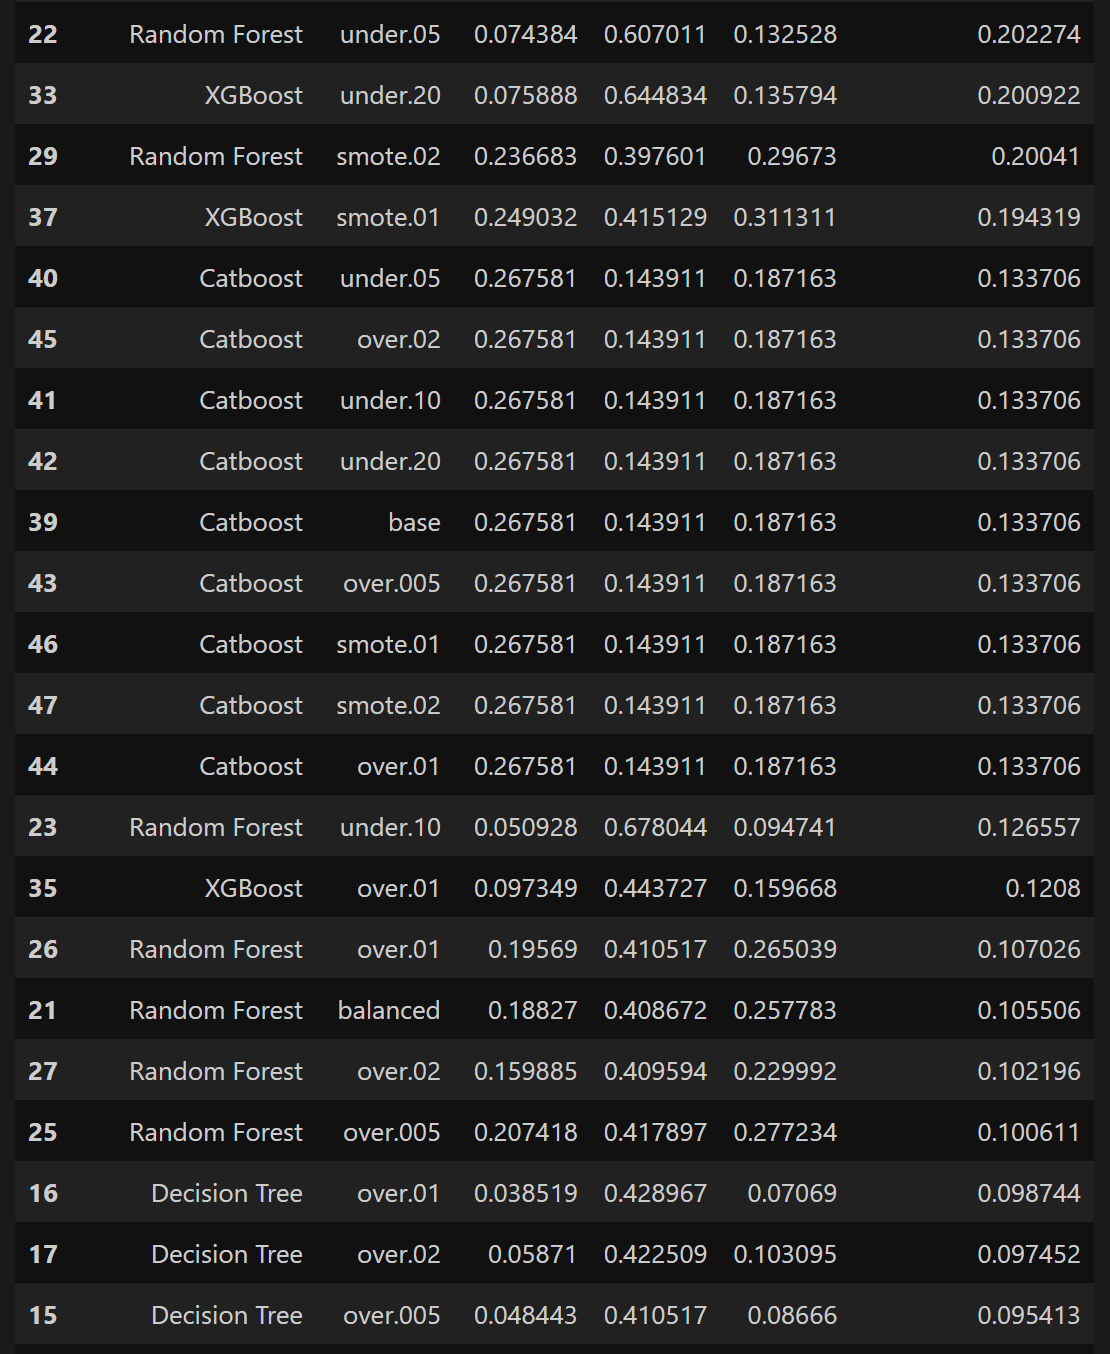
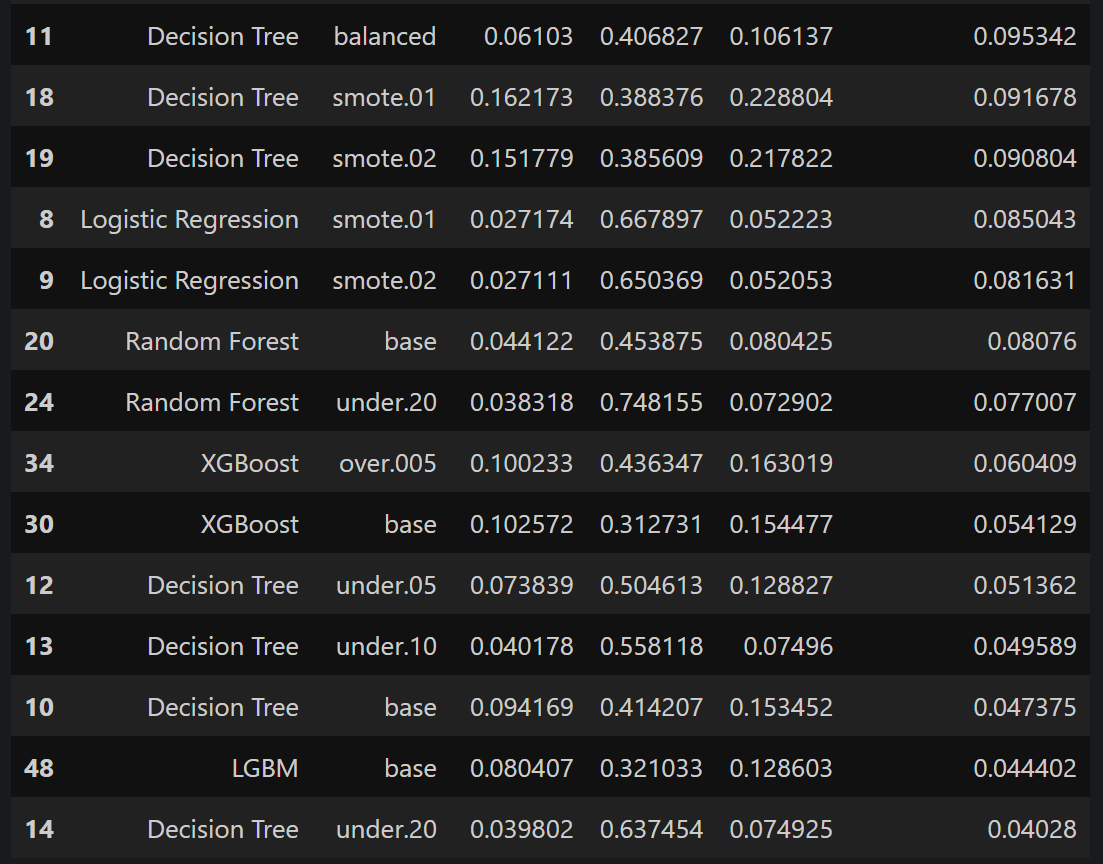